In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import json
import glob
from pathlib import Path
import numpy as np
import copy
import random

In [14]:
test_transform_dir = Path("../data/processed/test_transform")
test_transform_dir.mkdir(exist_ok=True)

In [ ]:
def apply_blur(image: np.ndarray, kernel_size: tuple[int, int] = (3, 3)) -> np.ndarray:
    """
    Applies Gaussian blur to *image*.
 
    Args:
        image:       Input image as a NumPy array.
        kernel_size: Blur kernel dimensions (width, height). Both values
                     must be odd positive integers.
 
    Returns:
        Blurred image as a NumPy array.
    """
    return cv2.GaussianBlur(image, kernel_size, sigmaX=0)

def rotate_image(mat, angle):
    """
    Rotates an image by *angle* degrees, expanding the canvas to avoid cropping.
 
    Args:
        mat:   Input image as a NumPy array (H x W x C).
        angle: Clockwise rotation angle in degrees.
 
    Returns:
        rotated_mat:     The rotated image.
        rotation_matrix: The 2x3 affine matrix used for the transform,
                         which can be passed to rotate_json_labels.
    """

    height, width = mat.shape[:2]
    center = (width / 2, height / 2)
 
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale=1.0)

    abs_cos = abs(rotation_matrix[0, 0])
    abs_sin = abs(rotation_matrix[0, 1])
 
    bound_w = int(height * abs_sin + width * abs_cos)
    bound_h = int(height * abs_cos + width * abs_sin)

    # Shift the rotation origin to the center of the new (expanded) canvas.
    rotation_matrix[0, 2] += bound_w / 2 - center[0]
    rotation_matrix[1, 2] += bound_h / 2 - center[1]
 
    rotated_mat = cv2.warpAffine(mat, rotation_matrix, (bound_w, bound_h))
    return rotated_mat, rotation_matrix

def rotate_json_labels(json_data, rotation_matrix):
    """
    Applies *rotation_matrix* to every marker corner stored in *json_data*.
 
    The function is non-destructive — it returns a deep copy and leaves
    the original dict unchanged.
 
    Args:
        json_data:       Dict with a ``"markers"`` key, each marker having
                         a ``"corners"`` list of [x, y] pairs.
        rotation_matrix: 2x3 affine matrix produced by :func:`rotate_image`.
 
    Returns:
        A new dict identical in structure to *json_data* but with all
        corner coordinates transformed.
    """
    rotated_data = copy.deepcopy(json_data)
    
    for marker in rotated_data.get("markers", []):
        rotated_corners = []
        for x, y in marker["corners"]:
            # Convert corner to homogeneous coordinates [x, y, 1]
            point = np.array([x, y, 1.0], dtype=np.float32)
            
            # Apply rotation matrix transformation
            new_x, new_y = rotation_matrix @ point
            
            # Extract x, y from result [new_x, new_y]
            rotated_corners.append([float(new_x), float(new_y)])
        marker["corners"] = rotated_corners
    
    return rotated_data

def transform_sample(
    image_path: Path | str,
    json_path: Path | str,
    output_dir: Path | str = test_transform_dir,
    angle: float | None = None,
) -> tuple[Path, Path]:
    """
    Applies rotation then Gaussian blur to a single image + label pair.

    Processing order: rotate → blur. Blur is intentionally applied after
    rotation so that label corner coordinates remain accurate (blurring
    does not shift pixel positions).

    Args:
        image_path: Path to the source image (.jpg / .jpeg / .png).
        json_path:  Path to the corresponding JSON label file.
        output_dir: Destination directory (created if it does not exist).
                    Defaults to ``data/processed/transform/``.
        angle:      Rotation angle in degrees. A random integer in [1, 359]
                    is used when *angle* is None.

    Returns:
        (out_image_path, out_json_path) — paths to the saved files.
    """
    image_path = Path(image_path)
    json_path = Path(json_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if angle is None:
        angle = random.randint(1, 359)

    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    with open(json_path, "r") as f:
        json_data = json.load(f)

    rotated_image, rotation_matrix = rotate_image(image, angle)
    transformed_image = apply_blur(rotated_image)
    transformed_json = rotate_json_labels(json_data, rotation_matrix)

    stem = image_path.stem
    out_image_path = output_dir / f"{stem}.jpg"
    out_json_path = output_dir / f"{stem}.json"

    cv2.imwrite(str(out_image_path), transformed_image)
    with open(out_json_path, "w") as f:
        json.dump(transformed_json, f, indent=4)

    return out_image_path, out_json_path

In [18]:
img_path = ["../data/raw/flyingarucov2/000000000089.jpg", "../data/raw/flyingarucov2/000000000315.jpg"]
json_path = ["../data/raw/flyingarucov2/000000000089.json", "../data/raw/flyingarucov2/000000000315.json"]

Transformed ../data/raw/flyingarucov2/000000000089.jpg → ..\data\processed\test_transform\000000000089.jpg
Transformed ../data/raw/flyingarucov2/000000000089.json → ..\data\processed\test_transform\000000000089.json


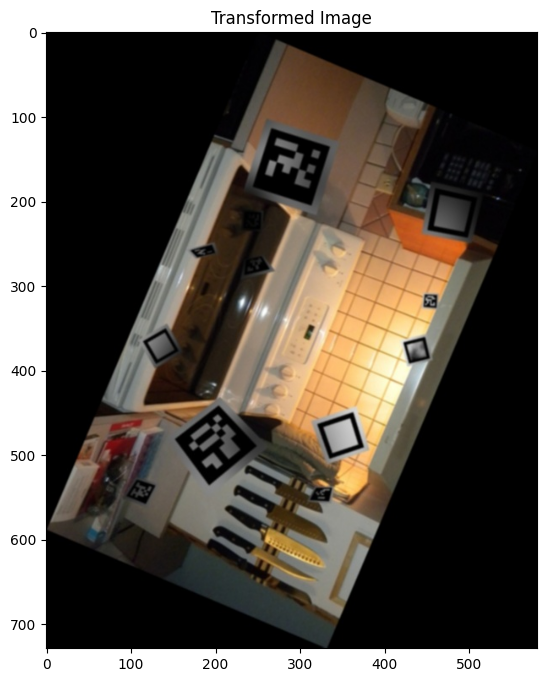

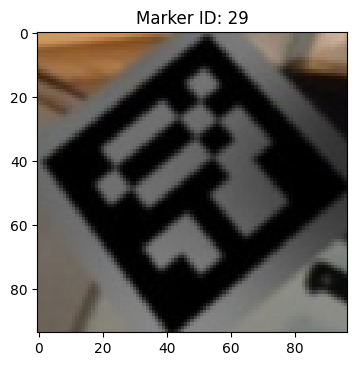

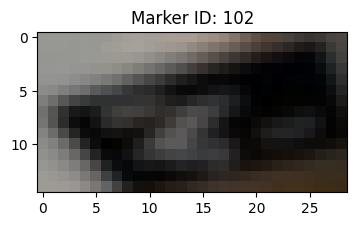

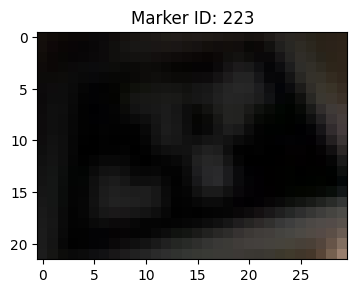

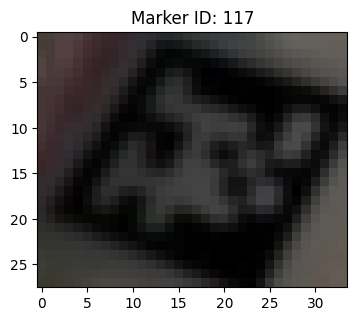

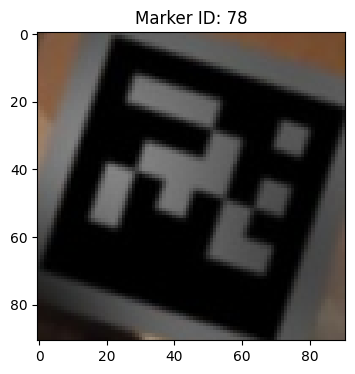

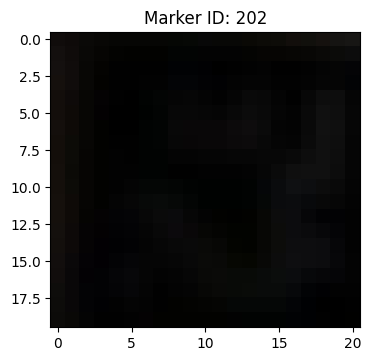

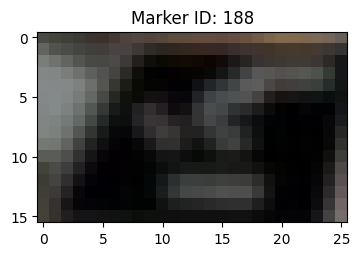

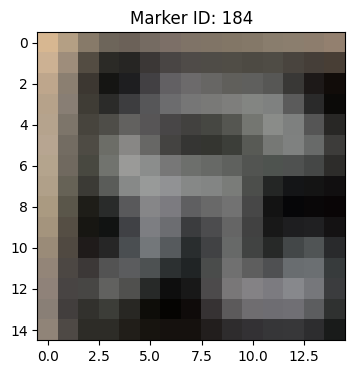

Transformed ../data/raw/flyingarucov2/000000000315.jpg → ..\data\processed\test_transform\000000000315.jpg
Transformed ../data/raw/flyingarucov2/000000000315.json → ..\data\processed\test_transform\000000000315.json


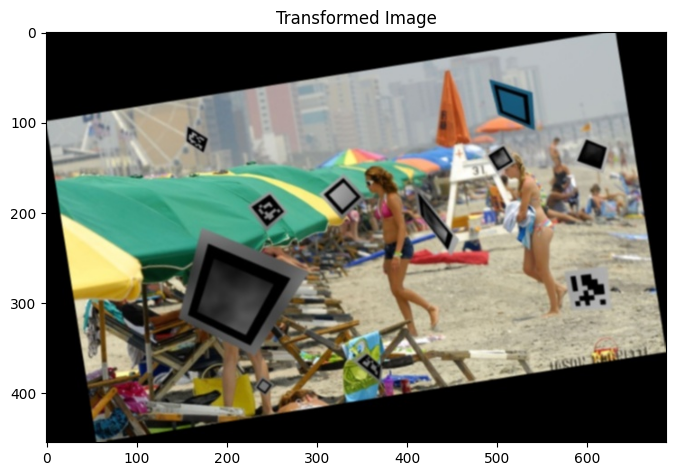

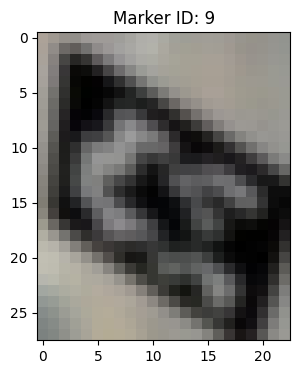

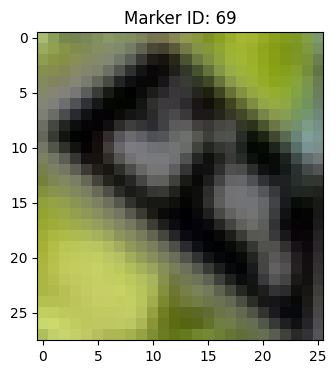

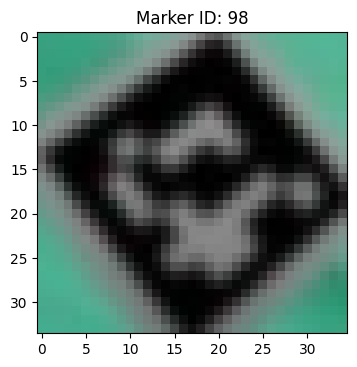

In [20]:
for img, js in zip(img_path, json_path):
    out_img, out_js = transform_sample(img, js)
    print(f"Transformed {img} → {out_img}")
    print(f"Transformed {js} → {out_js}")

    # Plot images after transformation (with box cropped by label corners)
    cv2.imread(str(out_img))
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(cv2.imread(str(out_img)), cv2.COLOR_BGR2RGB))
    plt.title("Transformed Image")
    plt.show()

    with open(out_js, "r") as f:
        data = json.load(f)

    for marker in data.get("markers", []):
        corners = marker["corners"]

        x_coords, y_coords = zip(*corners)
        x_min, x_max = min(x_coords), max(x_coords)
        y_min, y_max = min(y_coords), max(y_coords)

        # Load the transformed image
        img = cv2.imread(str(out_img))
        if img is None:
            print(f"Error: Could not load transformed image {out_img} for visualization.")
            continue

        # Crop the image using the bounding box defined by the corners
        cropped_img = img[int(y_min):int(y_max), int(x_min):int(x_max)]

        # Display the cropped image
        plt.figure(figsize=(4, 4))
        plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Marker ID: {marker['id']}")
        # plt.axis('off')
        plt.show()
